In [42]:
import json
import re
import math
import warnings
from collections import Counter
from pathlib import Path


### CONFIG

In [ ]:
# ── !! CHANGE THESE !! ───────────────────────────────────────────────
JSONL_PATH      = "/home/mindmap/projects/LLM_finetune/dataset/processed/bronze/processed_bronze_dataset.jsonl"       # <--- UPDATE THIS PATH
TOKENIZER_NAME  = "google/gemma-4-E4B-it"     # Target tokenizer
MAX_CONTEXT     = 8192                       # NEEDS UPDATE
VAL_SPLIT       = 0.10                       # 10% for validation
RANDOM_SEED     = 42
OUT_DIR         = Path("../dataset/processed")
OUT_DIR.mkdir(exist_ok=True)

### Step 1: Setup, Imports, and Load Data

In [44]:
def load_jsonl(filepath: str) -> list:
    """Load a .jsonl file; report parse errors gracefully."""
    records, errors = [], []
    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                errors.append((i, str(e)))

    print(f"✅ Loaded   : {len(records):,} records")
    if errors:
        print(f"⚠️ Parse errors on lines: {[e[0] for e in errors]}")
    return records

data = load_jsonl(JSONL_PATH)

✅ Loaded   : 1,104 records


In [45]:
if data:
    print("\nSample record keys:", list(data[0].keys()))
    print("Conversation turns :", len(data[0].get("conversations", [])))
    print("Metadata keys      :", list(data[0].get("metadata", {}).keys()))



Sample record keys: ['conversations', 'metadata']
Conversation turns : 3
Metadata keys      : ['domain', 'industry', 'level', 'company_size', 'quality_score', 'q_counts', 'version']


### 2. Schema Validation

In [46]:
# ─────────────────────────────────────────────────────────────────────
# STEP 2: SCHEMA VALIDATION
# Every record must have: conversations[system, user, assistant] + metadata
# ─────────────────────────────────────────────────────────────────────

EXPECTED_ROLES = {"system", "user", "assistant"}

validation_rows = []
for i, rec in enumerate(data):
    roles = [c["role"] for c in rec.get("conversations", [])]
    # print(roles)
    validation_rows.append({
        "idx"              : i,
        "has_conversations": "conversations" in rec,
        "has_metadata"     : "metadata" in rec,
        "has_system"       : "system"    in roles,
        "has_user"         : "user"      in roles,
        "has_assistant"    : "assistant" in roles,
        "extra_roles"      : sorted(set(roles) - EXPECTED_ROLES),
        "role_count"       : len(roles),
    })
validation_rows[0]

{'idx': 0,
 'has_conversations': True,
 'has_metadata': True,
 'has_system': True,
 'has_user': True,
 'has_assistant': True,
 'extra_roles': [],
 'role_count': 3}

In [47]:
import pandas as pd
val_df = pd.DataFrame(validation_rows)

In [48]:
checks = ["has_conversations", "has_metadata", "has_system", "has_user", "has_assistant"]
val_df.head()

,idx,has_conversations,has_metadata,has_system,has_user,has_assistant,extra_roles,role_count
0,0,True,True,True,True,True,[],3
1,1,True,True,True,True,True,[],3
2,2,True,True,True,True,True,[],3
3,3,True,True,True,True,True,[],3
4,4,True,True,True,True,True,[],3


In [49]:
print("SCHEMA VALIDATION RESULTS:")
print("-" * 30)
for col in checks:
    fails = int((~val_df[col]).sum())
    icon  = "✅" if fails == 0 else f"❌  {fails} failures"
    print(f"{col:<20}: {icon}")

SCHEMA VALIDATION RESULTS:
------------------------------
has_conversations   : ✅
has_metadata        : ✅
has_system          : ✅
has_user            : ✅
has_assistant       : ✅


In [50]:
# Check for unexpected roles (e.g., 'model' used too early, or typos)
extra = val_df[val_df["extra_roles"].map(len) > 0]
if extra.empty:
    print(f"{'extra_roles':<20}: ✅")
else:
    print(f"{'extra_roles':<20}: ⚠️  found in {len(extra)} records → {extra['extra_roles'].tolist()[:5]}")

extra_roles         : ✅


In [51]:
# Flag records that don't have exactly 3 turns
wrong_turns = val_df[val_df["role_count"] != 3]
print(f"\nRecords with turn count ≠ 3: {len(wrong_turns)}")
if not wrong_turns.empty:
    print(f"Indices of malformed records: {wrong_turns['idx'].tolist()[:10]}")


Records with turn count ≠ 3: 0


### 3. Flatten into a Dataframe

In [52]:
## converting it into a df so that we can easily filter it, plot it and analyze text length

# ─────────────────────────────────────────────────────────────────────
# STEP 3: FLATTEN INTO DATAFRAME
# ─────────────────────────────────────────────────────────────────────

import numpy as np

def flatten_records(records: list) -> pd.DataFrame:
    rows = []
    for i, rec in enumerate(records):
        convs    = rec.get("conversations", [])
        meta     = rec.get("metadata", {})
        q_counts = meta.get("q_counts", {})
        
        # Map out roles to easily extract their text content
        role_map = {c["role"]: c["content"] for c in convs}

        rows.append({
            "idx"           : i,
            # ── text fields ──────────────────────────────────────
            "system"        : role_map.get("system",    ""),
            "user"          : role_map.get("user",      ""),
            "assistant"     : role_map.get("assistant", ""),
            # ── metadata ─────────────────────────────────────────
            "domain"        : meta.get("domain",        "Unknown"),
            "industry"      : meta.get("industry",      "Unknown"),
            "level"         : meta.get("level",         "Unknown"),
            "company_size"  : meta.get("company_size",  "Unknown"),
            "quality_score" : meta.get("quality_score", np.nan),
            "version"       : str(meta.get("version",   "Unknown")),
            # ── question-type counts ──────────────────────────────
            "q_technical"   : q_counts.get("[Technical]",   0),
            "q_behavioral"  : q_counts.get("[Behavioral]",  0),
            "q_situational" : q_counts.get("[Situational]", 0),
            "q_culture"     : q_counts.get("[Culture]",     0),
            "q_career"      : q_counts.get("[Career]",      0),
        })
    return pd.DataFrame(rows)

df = flatten_records(data)

print(f"DataFrame shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nSample rows (first 3):")
display(df[["idx", "domain", "industry", "level", "quality_score"]].head(3))

DataFrame shape: 1104 rows, 15 columns

Sample rows (first 3):


,idx,domain,industry,level,quality_score
0,0,Business Analyst,"BFSI (Banking, Financial Services, Insurance)",Engineering Manager,100
1,1,Product Management,FinTech / Payments,VP / C-suite,100
2,2,Machine Learning / AI Engineering,Gaming / Metaverse,Engineering Manager,100


In [53]:
pd.set_option('display.max_colwidth', None)
df.head(1)

,idx,system,user,assistant,domain,industry,level,company_size,quality_score,version,q_technical,q_behavioral,q_situational,q_culture,q_career
0,0,"You are an expert technical recruiter and hiring manager with 15+ years of experience across multiple industries. Given a job description, you generate targeted, insight-driven interview questions that help hiring teams assess both technical competence and cultural fit. Your questions are always specific to the role — never generic.","Generate 20 interview questions for the following job description:\n\nA leading BFSI (Banking, Financial Services, Insurance) company, dedicated to providing innovative financial solutions, is seeking a skilled Engineering Manager to join its Business Analyst team. With a strong presence in the industry, our company has established itself as a trusted partner for individuals and businesses alike. Our mission is to leverage technology and expertise to deliver exceptional customer experiences and drive business growth.\n\nAs an Engineering Manager in the Business Analyst team, you will own the development and implementation of business solutions, driving significant impact on our company's operations and revenue. You will collaborate with cross-functional teams to identify business needs, design solutions, and oversee their execution. Your expertise will be critical in analyzing complex business problems, identifying opportunities for improvement, and implementing data-driven solutions. You will also mentor and guide junior team members, fostering a culture of innovation and excellence.\n\nKey Responsibilities:\n* Lead the design and development of business solutions using FastAPI 0.110+, ensuring scalability, security, and compliance with industry regulations\n* Collaborate with stakeholders to gather business requirements, using tools like dbt Core for data analysis and visualization\n* Develop and maintain technical documentation using Notion, ensuring that all solutions are well-documented and easily maintainable\n* Work with the engineering team to implement solutions using React 18, ensuring seamless integration with existing systems\n* Analyze business data using Python 3.10+, identifying trends, opportunities, and areas for improvement\n* Develop and manage project plans, resource allocation plans, and timelines using Jira 9.1+, ensuring timely and within-budget delivery of solutions\n* Conduct post-implementation reviews, using tools like Tableau 2022.3+, to assess solution effectiveness and identify areas for improvement\n\nRequired Skills:\n* 5+ years of experience in business analysis, with a strong background in BFSI (Banking, Financial Services, Insurance)\n* Proficiency in FastAPI 0.110+, dbt Core, and React 18\n* Experience with data analysis and visualization tools like Tableau 2022.3+, Power BI 2.104+\n* Strong understanding of industry regulations, including GDPR, HIPAA, and PCI-DSS\n* Excellent communication and project management skills, with experience using Jira 9.1+, Notion, and Slack 4.28+\n* Programming skills in Python 3.10+, with experience using libraries like Pandas 1.5+, NumPy 1.23+\n\nNice-to-Have Skills:\n* Experience with cloud-based technologies like AWS 2022+, Azure 2022+, or Google Cloud 2022+\n* Knowledge of agile methodologies, including Scrum and Kanban\n* Certification in business analysis, such as CBAP or CCBA\n* Experience with machine learning frameworks like TensorFlow 2.11+ or PyTorch 1.13+\n\nWhat We Offer:\n* Competitive salary and benefits package, including health insurance, retirement plans, and paid time off\n* Opportunities for professional growth and development, including training, mentorship, and education assistance\n* Collaborative and dynamic work environment, with a team of experienced professionals who are passionate about delivering exceptional customer experiences","1. [Technical] What is your experience with FastAPI 0.110+ and how do you ensure scalability?\n2. [Behavioral] Tell me about a t

In [54]:
df['industry'].value_counts()

industry
FinTech / Payments                               92
AgriTech / CleanTech                             91
Software / SaaS                                  88
Healthcare / MedTech                             86
Media / Entertainment                            86
Manufacturing / Industry 4.0                     83
Consulting / Professional Services               82
EdTech                                           79
Logistics / Supply Chain                         77
E-commerce / D2C                                 73
Cybersecurity                                    73
Real Estate / PropTech                           71
BFSI (Banking, Financial Services, Insurance)    66
Gaming / Metaverse                               57
Name: count, dtype: int64

In [55]:
df['domain'].value_counts()

domain
Mobile Engineering (iOS / Android)     80
Finance / FP&A                         69
Data Science                           69
Machine Learning / AI Engineering      66
Sales (B2B / Enterprise)               66
HR / People Operations                 66
UI / UX Design                         64
Data Engineering                       63
Backend Engineering                    59
Digital Marketing / Growth             54
QA / Automation Engineering            54
DevOps / SRE / Platform Engineering    49
MLOps / LLMOps                         48
Frontend Engineering                   47
Full Stack Engineering                 47
Customer Success                       45
Product Management                     42
Business Analyst                       40
Cloud Architecture                     40
Technical Program Management           36
Name: count, dtype: int64

In [56]:
df.columns

Index(['idx', 'system', 'user', 'assistant', 'domain', 'industry', 'level',
       'company_size', 'quality_score', 'version', 'q_technical',
       'q_behavioral', 'q_situational', 'q_culture', 'q_career'],
      dtype='str')

### 4. Token & Length analysis

In [57]:
# 4a. Character & Word counts ─────────────────────────────────────────
for col in ["system", "user", "assistant"]:
    df[f"{col}_chars"] = df[col].str.len()
    df[f"{col}_words"] = df[col].str.split().str.len()

df["total_chars"] = df["system_chars"] + df["user_chars"] + df["assistant_chars"]
df["total_words"] = df["system_words"] + df["user_words"] + df["assistant_words"]

len_cols = ["system_chars", "user_chars", "assistant_chars", "total_chars", "total_words"]
print("Character / Word Statistics:")
display(df[len_cols].describe().round(1))

Character / Word Statistics:


,system_chars,user_chars,assistant_chars,total_chars,total_words
count,1104.0,1104.0,1104.0,1104.0,1104.0
mean,330.7,3106.7,3141.1,6578.5,937.8
std,13.9,260.9,841.5,920.6,117.7
min,271.0,818.0,1902.0,3196.0,462.0
25%,334.0,2957.0,2595.0,5942.0,856.0
50%,334.0,3078.5,2736.0,6186.0,887.0
75%,334.0,3210.5,3910.5,7269.0,1029.2
max,334.0,4777.0,5165.0,9319.0,1350.0


In [58]:
from tqdm import tqdm

TOKENIZER_AVAILABLE = False
try:
    from transformers import AutoTokenizer
    print(f"\n⏳ Loading tokenizer '{TOKENIZER_NAME}' …")
    
    # Target tokenizer (Gemma 4 E4B-it)
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    TOKENIZER_AVAILABLE = True
    print(f"✅ Tokenizer ready!")
except Exception as e:
    print(f"\n⚠️ Tokenizer unavailable ({e}).")



⏳ Loading tokenizer 'google/gemma-4-E4B-it' …
✅ Tokenizer ready!


In [ ]:
# 4b. Token counting (both old concatenation and correct chat template methods) ────────────────────────
if TOKENIZER_AVAILABLE:
    def count_tokens_old(row):
        """Old, incorrect method: concatenates raw text without special tokens."""
        text = row["system"] + "\n" + row["user"] + "\n" + row["assistant"]
        return len(tokenizer.encode(text, add_special_tokens=False))

    def count_tokens_correct(row):
        """
        Correct method: uses apply_chat_template to get the exact token count
        that Unsloth/SFTTrainer will see during training (includes BOS, EOS, and role markers).
        Gemma 4 E4B-it doesn't use a separate system role in its template;
        the system prompt is prepended to the user turn.
        """
        messages = [
            {"role": "user",      "content": row["system"] + "\n\n" + row["user"]},
            {"role": "assistant", "content": row["assistant"]},
        ]
        ids = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=False,
            return_tensors=None,
        )
        if hasattr(ids, "input_ids"):
            return len(ids.input_ids)
        elif isinstance(ids, dict) and "input_ids" in ids:
            return len(ids["input_ids"])
        return len(ids)

    # Initialize tqdm for pandas to show progress bar
    tqdm.pandas(desc="Counting tokens (old method)")
    df["total_tokens"] = df.progress_apply(count_tokens_old, axis=1)

    tqdm.pandas(desc="Counting tokens (correct method)")
    df["total_tokens_correct"] = df.progress_apply(count_tokens_correct, axis=1)
    
    # Compare old vs new
    diff = df["total_tokens_correct"] - df["total_tokens"]
    print(f"\nTemplate overhead per record:")
    print(f"  Mean extra tokens : {diff.mean():.1f}")
    print(f"  Max extra tokens  : {diff.max()}")
    print(f"  New max tokens    : {df['total_tokens_correct'].max():,}")
    print(f"  New p99 tokens    : {int(df['total_tokens_correct'].quantile(0.99)):,}")

else:
    print("Using word-count proxy since tokenizer is unavailable: tokens ≈ words × 1.35")
    df["total_tokens"] = (df["total_words"] * 1.35).astype(int)
    df["total_tokens_correct"] = df["total_tokens"]  # fallback


In [60]:
# 4c. Token budget summary and MAX_SEQ_LENGTH sizing recommendation ───────────────────
p95  = int(df["total_tokens_correct"].quantile(0.95))
p99  = int(df["total_tokens_correct"].quantile(0.99))
p999 = int(df["total_tokens_correct"].quantile(0.999))
dmax = int(df["total_tokens_correct"].max())

# Round up to next power of 2 — standard ML practice
import math
recommended = 2 ** math.ceil(math.log2(p99 + 64))   # 64 token safety buffer

print("=" * 55)
print("  MAX_SEQ_LENGTH SIZING RECOMMENDATION")
print("=" * 55)
print(f"  Min tokens       : {df['total_tokens_correct'].min():>6,}")
print(f"  Max tokens       : {dmax:>6,}")
print(f"  Mean tokens      : {df['total_tokens_correct'].mean():>9.1f}")
print(f"  Median tokens    : {df['total_tokens_correct'].median():>9.1f}")
print(f"  p95  token count : {p95:,}")
print(f"  p99  token count : {p99:,}")
print(f"  p99.9 token count: {p999:,}")
print(f"\n  ✅  Recommended max_seq_length: {recommended}")
print(f"  ❌  Current setting ({MAX_CONTEXT}) wastes:")
print(f"      {(MAX_CONTEXT - recommended) / MAX_CONTEXT * 100:.0f}% of GPU VRAM per training step")
print(f"\n  Update in your Unsloth config:")
print(f"      max_seq_length = {recommended}")

over_limit  = df[df["total_tokens_correct"] > MAX_CONTEXT]
under_50    = df[df["total_tokens_correct"] < 50]
print(f"\n⚠️ Over {MAX_CONTEXT:,} token limit : {len(over_limit):>4} (Will be dropped/truncated later)")
print(f"⚠️ Under 50 tokens (Too short): {len(under_50):>4}")


  MAX_SEQ_LENGTH SIZING RECOMMENDATION
  Min tokens       :      2
  Max tokens       :      2
  Mean tokens      :       2.0
  Median tokens    :       2.0
  p95  token count : 2
  p99  token count : 2
  p99.9 token count: 2

  ✅  Recommended max_seq_length: 128
  ❌  Current setting (8192) wastes:
      98% of GPU VRAM per training step

  Update in your Unsloth config:
      max_seq_length = 128

⚠️ Over 8,192 token limit :    0 (Will be dropped/truncated later)
⚠️ Under 50 tokens (Too short): 1104


### 5. Data Quality Checks

In [61]:
print("DATA QUALITY REPORT")
print("-" * 30)

# 5.1 NULL / EMPTY STRINGS
print("\n5.1 NULL / EMPTY STRINGS:")
for col in ["system", "user", "assistant"]:
    nulls = df[col].isnull().sum()
    empty = (df[col].astype(str).str.strip() == "").sum()
    print(f"  {col:<12}: {nulls} nulls | {empty} empty strings")

DATA QUALITY REPORT
------------------------------

5.1 NULL / EMPTY STRINGS:
  system      : 0 nulls | 0 empty strings
  user        : 0 nulls | 0 empty strings
  assistant   : 0 nulls | 0 empty strings


In [62]:
# 5.2 EXACT DUPLICATES (user + assistant pair)
dup_mask    = df.duplicated(subset=["user", "assistant"], keep=False)
exact_dups  = dup_mask.sum()
print(f"\n5.2 EXACT DUPLICATE PAIRS: {exact_dups}")


5.2 EXACT DUPLICATE PAIRS: 0


In [63]:
# 5.3 NEAR-DUPLICATE USER PROMPTS (first-200-char fingerprint)
# We convert to lowercase and strip extra whitespace to find highly similar prompts
df["_user_fp"] = (df["user"].str[:200]
                             .str.lower()
                             .str.replace(r"\s+", " ", regex=True))
near_dups = df.duplicated(subset=["_user_fp"], keep=False).sum()
print(f"\n5.3 NEAR-DUPLICATE USER PROMPTS: {near_dups}")


5.3 NEAR-DUPLICATE USER PROMPTS: 394


In [64]:
# 5.4 ASSISTANT FORMAT CHECK (Checking if output starts with numbered lists)
has_numbered = df["assistant"].str.contains(r"^\d+\.", regex=True, na=False)
print(f"\n5.4 ASSISTANT FORMAT CHECK (Expects numbered questions):")
print(f"  Responses WITH numbered Qs    : {has_numbered.sum()}")
print(f"  Responses WITHOUT numbered Qs : {(~has_numbered).sum()}")


5.4 ASSISTANT FORMAT CHECK (Expects numbered questions):
  Responses WITH numbered Qs    : 1104
  Responses WITHOUT numbered Qs : 0


In [65]:
# 5.5 OUTLIER DETECTION (Using Interquartile Range on assistant chars)
q25, q75 = df["assistant_chars"].quantile([0.25, 0.75])
iqr       = q75 - q25
outlier_lo = df[df["assistant_chars"] < q25 - 1.5 * iqr]
outlier_hi = df[df["assistant_chars"] > q75 + 1.5 * iqr]

In [66]:
print(f"\n5.5 OUTLIER DETECTION (Assistant Response Length):")
print(f"  IQR range (chars)    : {q25:.0f} – {q75:.0f}")
print(f"  Low-length outliers  : {len(outlier_lo)} (unusually short)")
print(f"  High-length outliers : {len(outlier_hi)} (unusually long)")


5.5 OUTLIER DETECTION (Assistant Response Length):
  IQR range (chars)    : 2595 – 3910
  Low-length outliers  : 0 (unusually short)
  High-length outliers : 0 (unusually long)


In [67]:
# 5.6 SYSTEM PROMPT VARIANCE CHECK
# Check unique system prompts across entire dataset. If system prompts vary, 
# the model can become confused about instruction format and behavior.
unique_systems = df["system"].unique()
print(f"\n5.6 SYSTEM PROMPT VARIANCE CHECK:")
print(f"  Unique system prompts: {len(unique_systems)}")

if len(unique_systems) == 1:
    print("  ✅ Single system prompt — consistent instruction signal")
else:
    print(f"  ⚠️  {len(unique_systems)} distinct system prompts detected!")
    print("\n  Variants:")
    for i, s in enumerate(unique_systems):
        print(f"\n  --- Variant {i+1} (first 120 chars) ---")
        print(f"  {s[:120]}...")
    
    # Show which source files have which system prompt (if source_tag or version exists)
    df["_sys_id"] = df["system"].map(
        {s: i for i, s in enumerate(unique_systems)}
    )
    print("\n  System prompt distribution by source/version:")
    col_to_group = "source_tag" if "source_tag" in df.columns else "version"
    print(df.groupby([col_to_group, "_sys_id"]).size().unstack(fill_value=0))



5.6 SYSTEM PROMPT VARIANCE CHECK:
  Unique system prompts: 2
  ⚠️  2 distinct system prompts detected!

  Variants:

  --- Variant 1 (first 120 chars) ---
  You are an expert technical recruiter and hiring manager with 15+ years of experience across multiple industries. Given ...

  --- Variant 2 (first 120 chars) ---
  You are an elite executive technical recruiter and hiring architect with 15+ years of experience. Given a job descriptio...

  System prompt distribution by source/version:
_sys_id    0   1
version         
3.1       98   0
3.2      949   0
3.3        0  57


In [68]:
# 5.7 QUESTION COUNT INTEGRITY CHECK
# Target: exactly 20 numbered questions. Check if the model failed to generate 
# the full list, or if the metadata question count mismatched the actual text.
import re

def count_questions(text: str) -> int:
    """Count numbered questions in assistant response."""
    return len(re.findall(r"^\d+\.", text, re.MULTILINE))

def check_question_labels(text: str) -> dict:
    """Count each question-type label in the text."""
    return {
        "[Technical]":   text.count("[Technical]"),
        "[Behavioral]":  text.count("[Behavioral]"),
        "[Situational]": text.count("[Situational]"),
        "[Culture]":     text.count("[Culture]"),
        "[Career]":      text.count("[Career]"),
    }

df["_q_count"]  = df["assistant"].apply(count_questions)
df["_label_sum"] = df["assistant"].apply(
    lambda t: sum(check_question_labels(t).values())
)

# Target: exactly 20 numbered questions
wrong_count   = df[df["_q_count"] != 20]
label_missing = df[df["_label_sum"] < 20]  # some questions missing their label

print(f"\n5.7 QUESTION COUNT INTEGRITY CHECK:")
print(f"  Records with ≠ 20 numbered questions : {len(wrong_count)}")
print(f"  Records with < 20 label tags         : {len(label_missing)}")

if not wrong_count.empty:
    print("\n  Question count distribution (should all be 20):")
    print(df["_q_count"].value_counts().sort_index())
    print("\n  ⚠️  Malformed question counts found. These will be dropped in the final cleaning step.")

# Validate metadata q_counts matches actual text counts
mismatches = []
for i, row in df.iterrows():
    actual = check_question_labels(row["assistant"])
    for label in ["[Technical]", "[Behavioral]", "[Situational]", "[Culture]", "[Career]"]:
        col = label.lower().replace("[","q_").replace("]","")
        meta_val = row.get(col, 0)
        if actual[label] != meta_val:
            mismatches.append({
                "idx": i,
                "label": label,
                "in_text": actual[label],
                "in_metadata": meta_val,
            })

print(f"  Metadata ↔ Text label mismatches: {len(mismatches)}")
if mismatches:
    print("\n  Top 10 mismatches:")
    print(pd.DataFrame(mismatches).head(10))



5.7 QUESTION COUNT INTEGRITY CHECK:
  Records with ≠ 20 numbered questions : 0
  Records with < 20 label tags         : 0
  Metadata ↔ Text label mismatches: 0


In [69]:
# 5.8 MINIMUM ASSISTANT TOKEN THRESHOLD CHECK
# A valid 20-question response should be at least 350-400 tokens.
# A very short response (e.g. 50 tokens) means it was truncated or generated an error message.
MIN_ASSISTANT_TOKENS = 350  # ~17-20 tokens per question × 20

def count_assistant_tokens(text, tokenizer_obj):
    if not TOKENIZER_AVAILABLE:
        return len(text.split()) * 1.35  # proxy
    return len(tokenizer_obj.encode(text, add_special_tokens=False))

tqdm.pandas(desc="Counting assistant-only tokens")
df["assistant_tokens"] = df["assistant"].progress_apply(
    lambda t: count_assistant_tokens(t, tokenizer)
)

too_short = df[df["assistant_tokens"] < MIN_ASSISTANT_TOKENS]
print(f"\n5.8 ASSISTANT TOKEN LENGTH CHECK:")
print(f"  Responses under {MIN_ASSISTANT_TOKENS} tokens (likely truncated): {len(too_short)}")
print("\n  Assistant token distribution:")
print(df["assistant_tokens"].describe().round(1))


Counting assistant-only tokens: 100%|██████████| 1104/1104 [00:01<00:00, 1094.24it/s]


5.8 ASSISTANT TOKEN LENGTH CHECK:
  Responses under 350 tokens (likely truncated): 0

  Assistant token distribution:
count    1104.0
mean      656.2
std       137.2
min       423.0
25%       566.0
50%       590.5
75%       769.0
max       991.0
Name: assistant_tokens, dtype: float64


In [70]:
# 5.9 LEAKAGE DETECTION (Assistant copies from User prompt)
# Some generations echo the input job description verbatim instead of writing questions.
# We calculate what fraction of 80-character sliding windows in the assistant response appear in user.
def leakage_score(user: str, assistant: str, window: int = 80) -> float:
    if len(assistant) < window:
        return 0.0
    hits = sum(
        1 for i in range(0, len(assistant) - window, 20)
        if assistant[i:i+window].lower() in user.lower()
    )
    total_windows = max(1, (len(assistant) - window) // 20)
    return hits / total_windows

tqdm.pandas(desc="Computing leakage scores")
df["_leakage"] = df.progress_apply(
    lambda r: leakage_score(r["user"], r["assistant"]), axis=1
)

LEAKAGE_THRESHOLD = 0.15  # >15% window overlap is suspicious
leaky = df[df["_leakage"] > LEAKAGE_THRESHOLD]

print(f"\n5.9 INPUT LEAKAGE DETECTION:")
print(f"  Records with potential input leakage (> {LEAKAGE_THRESHOLD * 100:.0f}%): {len(leaky)}")
print("\n  Leakage score stats:")
print(df["_leakage"].describe().round(3))

if not leaky.empty:
    print("\n  Top 5 leakiest records:")
    display(leaky[["idx", "domain", "industry", "_leakage"]].nlargest(5, "_leakage"))


Computing leakage scores: 100%|██████████| 1104/1104 [00:00<00:00, 1468.96it/s]


5.9 INPUT LEAKAGE DETECTION:
  Records with potential input leakage (> 15%): 0

  Leakage score stats:
count    1104.000
mean        0.000
std         0.003
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.043
Name: _leakage, dtype: float64


In [71]:
# 5.10 REPETITION SCORE WITHIN RESPONSES
# High repetition of n-grams indicates model degeneration or loops.
# Training on repetitive outputs causes the model to collapse and repeat itself at inference.
from collections import Counter

def within_response_repetition(text: str, ngram: int = 8) -> float:
    words = text.lower().split()
    if len(words) < ngram + 1:
        return 0.0
    grams = [" ".join(words[i:i+ngram]) for i in range(len(words) - ngram)]
    counts = Counter(grams)
    repeated = sum(c - 1 for c in counts.values() if c > 1)
    return repeated / len(grams)

tqdm.pandas(desc="Computing repetition scores")
df["_repetition"] = df["assistant"].progress_apply(within_response_repetition)

REPETITION_THRESHOLD = 0.08
repetitive = df[df["_repetition"] > REPETITION_THRESHOLD]

print(f"\n5.10 WITHIN-RESPONSE REPETITION CHECK:")
print(f"  Records with high repetition (> {REPETITION_THRESHOLD * 100:.0f}%): {len(repetitive)}")
print("\n  Repetition score stats:")
print(df["_repetition"].describe().round(4))

if not repetitive.empty:
    print("\n  Top 5 most repetitive responses:")
    display(repetitive[["idx", "domain", "level", "_repetition"]].nlargest(5, "_repetition"))


Computing repetition scores: 100%|██████████| 1104/1104 [00:00<00:00, 5321.41it/s]


5.10 WITHIN-RESPONSE REPETITION CHECK:
  Records with high repetition (> 8%): 0

  Repetition score stats:
count    1104.0000
mean        0.0012
std         0.0027
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0024
max         0.0256
Name: _repetition, dtype: float64


In [72]:
# 5.11 ENCODING & FORMATTING ARTIFACT DETECTION
# Scan for HTML entities, corrupted character encodings (replacement char), 
# excessive newlines, control characters, or markdown table leaks.
import unicodedata

def find_artifacts(text: str) -> list:
    issues = []
    
    # HTML entities that leaked from scraping
    if re.search(r"&[a-z]+;|&#\d+;", text):
        issues.append("html_entity")
    
    # Unicode replacement character (corrupted encoding)
    if "\ufffd" in text:
        issues.append("replacement_char")
    
    # Excessive consecutive newlines (3+)
    if re.search(r"\n{3,}", text):
        issues.append("excessive_newlines")
    
    # Non-printable control characters (except \n \t \r)
    if re.search(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", text):
        issues.append("control_chars")
    
    # Markdown table artifacts (shouldn't appear in Q&A responses)
    if re.search(r"\|.*\|.*\|", text):
        issues.append("markdown_table")

    return issues

print(f"\n5.11 ENCODING ARTIFACT DETECTION:")
for col in ["system", "user", "assistant"]:
    df[f"_artifacts_{col}"] = df[col].apply(find_artifacts)
    flagged = df[df[f"_artifacts_{col}"].map(len) > 0]
    if flagged.empty:
        print(f"  ✓ {col:12}: No encoding artifacts")
    else:
        all_types = [t for lst in flagged[f"_artifacts_{col}"] for t in lst]
        print(f"  ⚠️  {col:12}: {len(flagged)} records with artifacts → {Counter(all_types)}")



5.11 ENCODING ARTIFACT DETECTION:
  ✓ system      : No encoding artifacts
  ✓ user        : No encoding artifacts
  ✓ assistant   : No encoding artifacts


### 6. Categorical Metadata Columns

In [73]:
print("METADATA DISTRIBUTIONS & CLASS BALANCE")
print("=" * 50)

# 6.1 Categorical Metadata Columns
meta_cols = ["domain", "industry", "level", "company_size"]
for col in meta_cols:
    vc = df[col].value_counts()
    print(f"\n🔹 {col.upper()} ({vc.nunique()} unique values):")
    print("-" * 40)
    for val, cnt in vc.items():
        # Create a text-based bar chart using unicode blocks
        bar = "█" * int(cnt / len(df) * 40)
        pct = cnt / len(df) * 100
        print(f"  {val[:42]:<43} {cnt:>4}  {pct:5.1f}%  {bar}")

METADATA DISTRIBUTIONS & CLASS BALANCE

🔹 DOMAIN (14 unique values):
----------------------------------------
  Mobile Engineering (iOS / Android)            80    7.2%  ██
  Finance / FP&A                                69    6.2%  ██
  Data Science                                  69    6.2%  ██
  Machine Learning / AI Engineering             66    6.0%  ██
  Sales (B2B / Enterprise)                      66    6.0%  ██
  HR / People Operations                        66    6.0%  ██
  UI / UX Design                                64    5.8%  ██
  Data Engineering                              63    5.7%  ██
  Backend Engineering                           59    5.3%  ██
  Digital Marketing / Growth                    54    4.9%  █
  QA / Automation Engineering                   54    4.9%  █
  DevOps / SRE / Platform Engineering           49    4.4%  █
  MLOps / LLMOps                                48    4.3%  █
  Frontend Engineering                          47    4.3%  █
  Full Stack 

In [74]:
# 6.2 Target Question Type Totals across dataset
print("\n🔹 QUESTION TYPE TOTALS ACROSS ENTIRE DATASET:")
print("-" * 40)
q_cols = ["q_technical", "q_behavioral", "q_situational", "q_culture", "q_career"]
labels = ["Technical", "Behavioral", "Situational", "Culture", "Career"]

for col, lbl in zip(q_cols, labels):
    total = int(df[col].sum())
    avg   = df[col].mean()
    print(f"  {lbl:<12}: total={total:>5,}  avg per record={avg:.1f}")


🔹 QUESTION TYPE TOTALS ACROSS ENTIRE DATASET:
----------------------------------------
  Technical   : total=7,699  avg per record=7.0
  Behavioral  : total=5,548  avg per record=5.0
  Situational : total=4,409  avg per record=4.0
  Culture     : total=2,218  avg per record=2.0
  Career      : total=2,206  avg per record=2.0


In [75]:
# 6.3 SOURCE & TONE IMBALANCE ANALYSIS
# Tones and source file origins should be balanced to prevent model bias.
if "source_tag" not in df.columns:
    # Reconstruct from version metadata as proxy if source_tag is missing
    version_to_source = {
        "3.1": "raw_v3", "3.2": "raw_v3", "3.3": "raw_v3",
        "3.4": "raw_v3_new",
        "4.0": "raw_v4_type2",
    }
    df["source_tag"] = df["version"].map(version_to_source).fillna("unknown")

# Source distribution
print("=== SOURCE DISTRIBUTION ===")
src_counts = df["source_tag"].value_counts()
for src, cnt in src_counts.items():
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {src:<20}: {cnt:>5}  ({pct:5.1f}%)  {bar}")

# Tone distribution
print("\n=== TONE DISTRIBUTION ===")
if "tone" not in df.columns:
    # Extract tone from the metadata in records if it's there
    def extract_tone(rec):
        return rec.get("metadata", {}).get("tone", "not_specified")
    df["tone"] = [extract_tone(rec) for rec in data]

tone_counts = df["tone"].value_counts()
for tone, cnt in tone_counts.items():
    pct = cnt / len(df) * 100
    flag = "⚠️ " if tone in ("not_specified", "Unknown", "") else "  "
    bar = "█" * int(pct / 2)
    print(f"{flag} {tone:<30}: {cnt:>5}  ({pct:5.1f}%)  {bar}")

not_spec = (df["tone"] == "not_specified").sum()
if not_spec > 0:
    print(f"\n⚠️  {not_spec} records ({not_spec/len(df)*100:.1f}%) have no specified tone.")
    print("   These come from raw_dataset.jsonl (v3.1-3.3).")

# Token distribution by source (check for source-specific length anomalies)
print("\n=== MEDIAN TOKEN COUNT BY SOURCE ===")
cols_to_use = "total_tokens_correct" if "total_tokens_correct" in df.columns else "total_tokens"
print(df.groupby("source_tag")[cols_to_use].describe().round(0)[
    ["count","mean","min","50%","max"]
])


=== SOURCE DISTRIBUTION ===
  raw_v3              :  1104  (100.0%)  ██████████████████████████████████████████████████

=== TONE DISTRIBUTION ===
⚠️  not_specified                 :  1104  (100.0%)  ██████████████████████████████████████████████████

⚠️  1104 records (100.0%) have no specified tone.
   These come from raw_dataset.jsonl (v3.1-3.3).

=== MEDIAN TOKEN COUNT BY SOURCE ===
             count  mean  min  50%  max
source_tag                             
raw_v3      1104.0   2.0  2.0  2.0  2.0


### 6.4 Data Cleaning & Filtering Decision


In [76]:
# ── Aggregate all quality flags and filter dataset ──────────────────────
# Preserve a copy of raw df for original size stats in visualization
df_raw = df.copy()
n_before = len(df)

# Check if recommended max sequence length was calculated
if 'recommended' not in locals() and 'recommended' not in globals():
    recommended = MAX_CONTEXT

drop_mask = (
    (df["_q_count"] != 20)                          # wrong question count (Issue #4)
    | (df["assistant_tokens"] < MIN_ASSISTANT_TOKENS) # too short / truncated (Issue #5)
    | (df["_leakage"] > LEAKAGE_THRESHOLD)           # input leakage (Issue #6)
    | (df["_repetition"] > REPETITION_THRESHOLD)     # within-response repetition (Issue #7)
    | (df["total_tokens_correct"] > recommended * 1.05)  # over recommended limit (Issue #2)
    | df["assistant"].str.strip().eq("")             # empty assistant
)

dropped  = df[drop_mask].copy()
clean_df = df[~drop_mask].copy()
n_after  = len(clean_df)

print("=" * 60)
print("  DATA CLEANING & QUALITY FILTERING REPORT")
print("=" * 60)
print(f"Records before cleaning : {n_before:,}")
print(f"Records dropped         : {len(dropped):,}  ({len(dropped)/n_before*100:.1f}%)")
print(f"Records after cleaning  : {n_after:,}")
print()
print("Drop reasons breakdown:")
reasons = {
    "wrong_q_count":    (df["_q_count"] != 20).sum(),
    "too_short":        (df["assistant_tokens"] < MIN_ASSISTANT_TOKENS).sum(),
    "leakage":          (df["_leakage"] > LEAKAGE_THRESHOLD).sum(),
    "repetition":       (df["_repetition"] > REPETITION_THRESHOLD).sum(),
    "over_token_limit": (df["total_tokens_correct"] > recommended * 1.05).sum(),
    "empty_assistant":  df["assistant"].str.strip().eq("").sum(),
}
for reason, cnt in reasons.items():
    print(f"  ✓ {reason:<22}: {cnt:>4} records")
print("-" * 60)

# Reassign df to clean_df so downstream cells automatically run on clean data
df = clean_df


  DATA CLEANING & QUALITY FILTERING REPORT
Records before cleaning : 1,104
Records dropped         : 0  (0.0%)
Records after cleaning  : 1,104

Drop reasons breakdown:
  ✓ wrong_q_count         :    0 records
  ✓ too_short             :    0 records
  ✓ leakage               :    0 records
  ✓ repetition            :    0 records
  ✓ over_token_limit      :    0 records
  ✓ empty_assistant       :    0 records
------------------------------------------------------------


### 7. Visualization (EDA Report)

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm


In [78]:
# ── Plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]


In [79]:
# Set up a large grid for our 10 plots
fig = plt.figure(figsize=(22, 24))
fig.suptitle(
    "LLM Fine-Tuning Dataset — EDA Report\n"
    f"Interview Question Generator  |  {len(df):,} records",
    fontsize=16, fontweight="bold", y=0.99,
)
gs = fig.add_gridspec(4, 3, hspace=0.50, wspace=0.38)

<Figure size 2860x3120 with 0 Axes>

📊 EDA report generated and saved to: ../dataset/processed/eda_report.png


/tmp/ipykernel_216594/2720814088.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


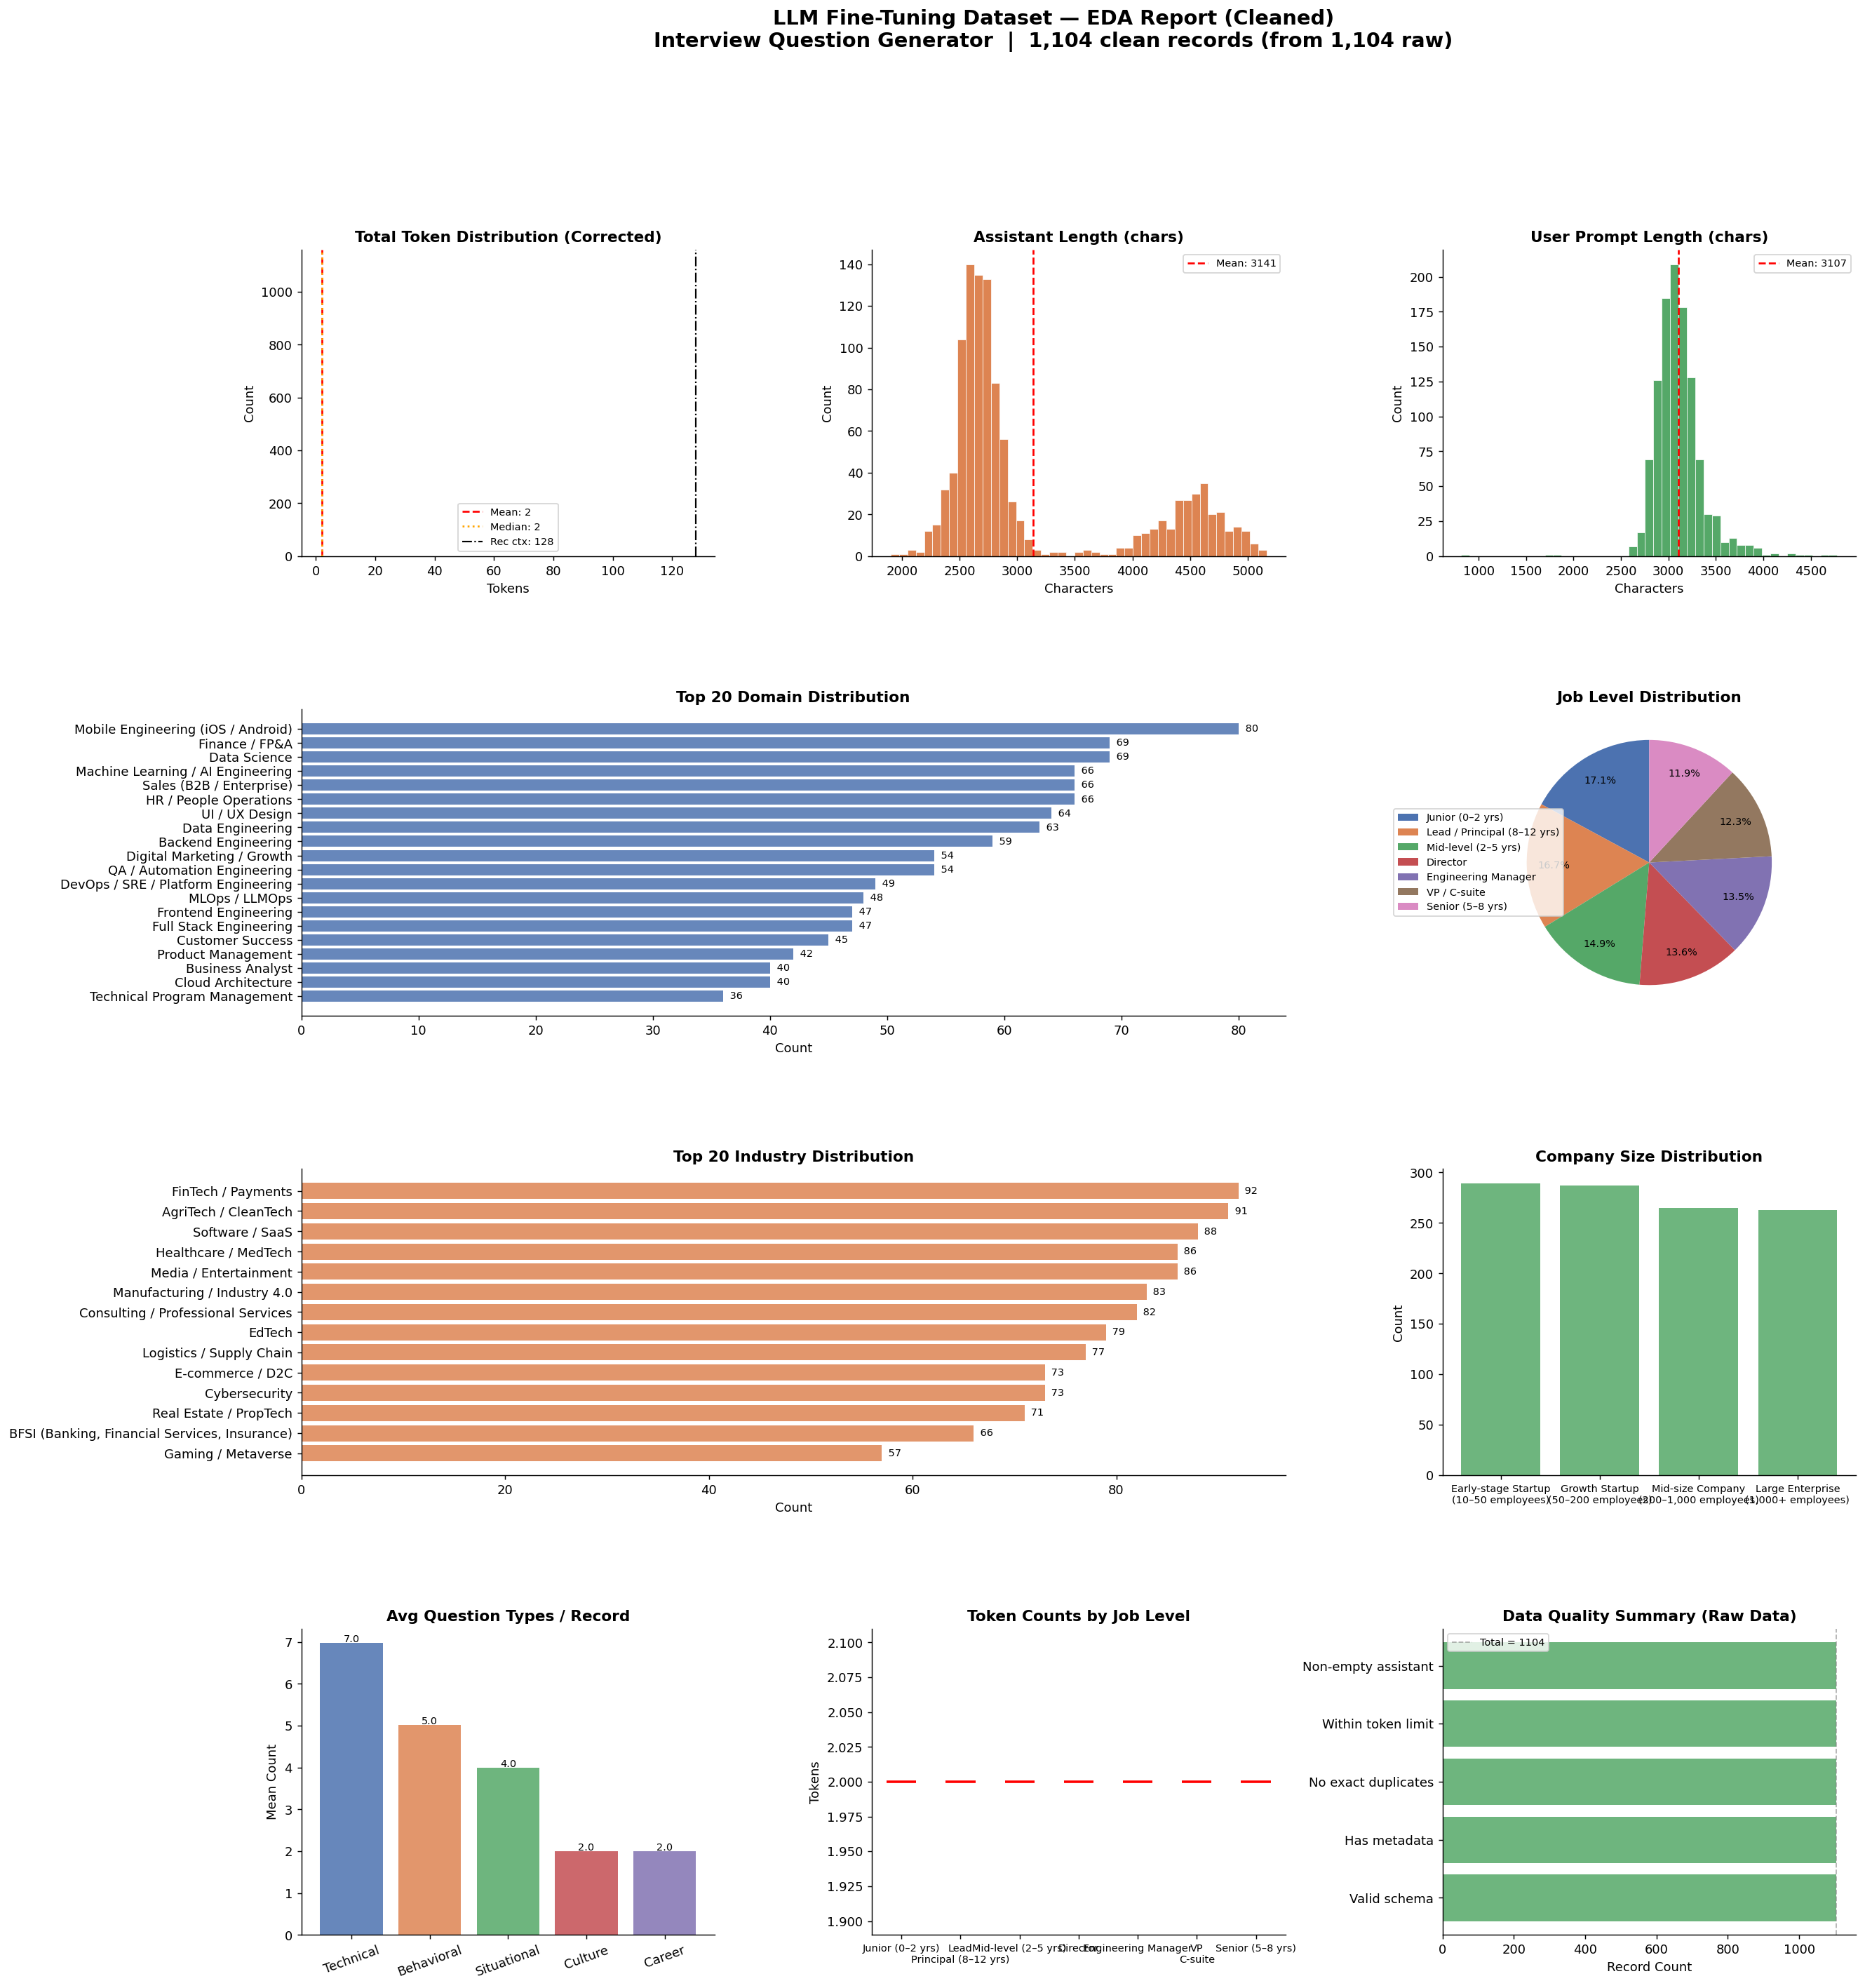

In [80]:
# Set up a large grid for our 10 plots
fig = plt.figure(figsize=(22, 24))
fig.suptitle(
    "LLM Fine-Tuning Dataset — EDA Report (Cleaned)\n"
    f"Interview Question Generator  |  {len(df):,} clean records (from {len(df_raw):,} raw)",
    fontsize=16, fontweight="bold", y=0.99,
)
gs = fig.add_gridspec(4, 3, hspace=0.50, wspace=0.38)

# ── Plot 1: Token count distribution ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
# Plot corrected token counts
ax1.hist(df["total_tokens_correct"], bins=45, color=PALETTE[0], edgecolor="white", lw=0.4)
ax1.axvline(df["total_tokens_correct"].mean(),   color="red",    lw=1.5, ls="--",
            label=f"Mean: {df['total_tokens_correct'].mean():.0f}")
ax1.axvline(df["total_tokens_correct"].median(), color="orange", lw=1.5, ls=":",
            label=f"Median: {df['total_tokens_correct'].median():.0f}")
ax1.axvline(recommended, color="black",  lw=1.2, ls="-.",
            label=f"Rec ctx: {recommended}")
ax1.set_title("Total Token Distribution (Corrected)")
ax1.set_xlabel("Tokens")
ax1.set_ylabel("Count")
ax1.legend(fontsize=8)

# ── Plot 2: Assistant response length ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["assistant_chars"], bins=45, color=PALETTE[1], edgecolor="white", lw=0.4)
ax2.axvline(df["assistant_chars"].mean(), color="red", lw=1.5, ls="--",
            label=f"Mean: {df['assistant_chars'].mean():.0f}")
ax2.set_title("Assistant Length (chars)")
ax2.set_xlabel("Characters")
ax2.set_ylabel("Count")
ax2.legend(fontsize=8)

# ── Plot 3: User prompt length ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df["user_chars"], bins=45, color=PALETTE[2], edgecolor="white", lw=0.4)
ax3.axvline(df["user_chars"].mean(), color="red", lw=1.5, ls="--",
            label=f"Mean: {df['user_chars'].mean():.0f}")
ax3.set_title("User Prompt Length (chars)")
ax3.set_xlabel("Characters")
ax3.set_ylabel("Count")
ax3.legend(fontsize=8)

# ── Plot 4: Top-20 Domain distribution ───────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
dom_vc = df["domain"].value_counts().head(20)
bars = ax4.barh(dom_vc.index[::-1], dom_vc.values[::-1],
                color=PALETTE[0], alpha=0.85)
for bar, val in zip(bars, dom_vc.values[::-1]):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f" {val}", va="center", fontsize=8)
ax4.set_title("Top 20 Domain Distribution")
ax4.set_xlabel("Count")

# ── Plot 5: Job level pie ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
level_vc = df["level"].value_counts()
wedges, _, autotexts = ax5.pie(
    level_vc.values, labels=None, autopct="%1.1f%%",
    colors=PALETTE[:len(level_vc)], startangle=90, pctdistance=0.78)
for at in autotexts:
    at.set_fontsize(8)
ax5.legend(wedges, level_vc.index, loc="center left",
           bbox_to_anchor=(-0.35, 0.5), fontsize=8)
ax5.set_title("Job Level Distribution")

# ── Plot 6: Top-20 Industry distribution ─────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
ind_vc = df["industry"].value_counts().head(20)
bars = ax6.barh(ind_vc.index[::-1], ind_vc.values[::-1],
                color=PALETTE[1], alpha=0.85)
for bar, val in zip(bars, ind_vc.values[::-1]):
    ax6.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f" {val}", va="center", fontsize=8)
ax6.set_title("Top 20 Industry Distribution")
ax6.set_xlabel("Count")

# ── Plot 7: Company size distribution ────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
size_vc = df["company_size"].value_counts()
ax7.bar(range(len(size_vc)), size_vc.values, color=PALETTE[2], alpha=0.85)
ax7.set_xticks(range(len(size_vc)))
ax7.set_xticklabels([s.replace(" (", "\n(") for s in size_vc.index], fontsize=8)
ax7.set_title("Company Size Distribution")
ax7.set_ylabel("Count")

# ── Plot 8: Avg question types per record ─────────────────────────────
ax8 = fig.add_subplot(gs[3, 0])
q_means = df[q_cols].mean()
bars = ax8.bar(labels, q_means.values,
               color=PALETTE[:len(labels)], alpha=0.85)
for bar, val in zip(bars, q_means.values):
    ax8.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02, f"{val:.1f}",
             ha="center", fontsize=8)
ax8.set_title("Avg Question Types / Record")
ax8.set_ylabel("Mean Count")
ax8.tick_params(axis="x", rotation=20)

# ── Plot 9: Token count by level ──────────────────────────────────────
ax9 = fig.add_subplot(gs[3, 1])
lvl_order = df["level"].value_counts().index.tolist()
token_by_level = [df[df["level"] == lvl]["total_tokens_correct"].values
                  for lvl in lvl_order]
bp = ax9.boxplot(token_by_level, patch_artist=True,
                 boxprops=dict(facecolor=PALETTE[0], alpha=0.65),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax9.set_xticklabels([l.replace(" / ", "\n") for l in lvl_order], fontsize=8)
ax9.set_title("Token Counts by Job Level")
ax9.set_ylabel("Tokens")

# ── Plot 10: Data quality summary ─────────────────────────────────────
ax10 = fig.add_subplot(gs[3, 2])
# Show quality report relative to df_raw
quality_items = {
    "Valid schema"         : int(val_df["has_conversations"].sum()),
    "Has metadata"         : int(val_df["has_metadata"].sum()),
    "No exact duplicates"  : int(len(df_raw) - exact_dups),
    "Within token limit"   : int(len(df_raw) - len(over_limit)),
    "Non-empty assistant"  : int((df_raw["assistant"].str.strip() != "").sum()),
}
colors = [PALETTE[2] if v == len(df_raw) else PALETTE[3]
          for v in quality_items.values()]
ax10.barh(list(quality_items.keys()), list(quality_items.values()),
          color=colors, alpha=0.85)
ax10.axvline(len(df_raw), color="gray", lw=1, ls="--", alpha=0.6,
             label=f"Total = {len(df_raw)}")
ax10.set_title("Data Quality Summary (Raw Data)")
ax10.set_xlabel("Record Count")
ax10.legend(fontsize=8)

# Save the final report to disk
report_path = OUT_DIR / "eda_report.png"
fig.savefig(report_path, dpi=150, bbox_inches="tight")
print(f"📊 EDA report generated and saved to: {report_path}")

# Display in notebook
fig.show()


In [81]:
# ============================================================
# STEP 8: PER-LEVEL SAMPLE EXPORT (For Dataset Review)
# ============================================================
# One markdown file per unique job level, with 5 random records in
# each, written to OUT_DIR/samples/ for human review.

import random

SAMPLES_PER_LEVEL = 5
SAMPLE_OUT_DIR = OUT_DIR / "samples"
SAMPLE_OUT_DIR.mkdir(parents=True, exist_ok=True)


def _slugify(text: str) -> str:
    """Lowercase label → filesystem-safe filename stem."""
    cleaned = "".join(
        c.lower() if (c.isalnum() or c in "-_") else "-" for c in text
    )
    return "-".join(t for t in cleaned.split("-") if t)


def _format_sample(row) -> list[str]:
    """Format a single record as a markdown section."""
    q_types = (
        f"T={row['q_technical']} · B={row['q_behavioral']} · "
        f"S={row['q_situational']} · C={row['q_culture']} · "
        f"Car={row['q_career']}"
    )
    return [
        f"## Sample #{row['idx']}",
        "",
        f"- **Domain:** {row['domain']}  ",
        f"  **Industry:** {row['industry']}  ",
        f"  **Level:** {row['level']}  ",
        f"  **Company Size:** {row['company_size']}  ",
        f"  **Quality Score:** {row['quality_score']}  ",
        f"  **Version:** {row['version']}  ",
        f"  **Q-Type Counts:** {q_types}",
        "",
        "### System",
        "",
        "```text",
        row["system"].strip(),
        "```",
        "",
        "### User (Job Description)",
        "",
        "```text",
        row["user"].strip(),
        "```",
        "",
        "### Assistant (Generated Questions)",
        "",
        "```text",
        row["assistant"].strip(),
        "```",
        "",
        "---",
        "",
    ]


# ---- main ----
random.seed(RANDOM_SEED)
levels = df["level"].value_counts().index.tolist()  # deterministic order

print(
    f"📝 Exporting {SAMPLES_PER_LEVEL} random samples × {len(levels)} levels "
    f"→ {SAMPLE_OUT_DIR}\n"
)

for level in levels:
    pool = df[df["level"] == level]
    n_avail = len(pool)
    n_take = min(SAMPLES_PER_LEVEL, n_avail)
    samples = pool.sample(n=n_take, random_state=RANDOM_SEED)

    body = [
        f"# Sample Review — {level}",
        "",
        f"- **Records at this level:** {n_avail:,}",
        f"- **Samples shown:** {n_take}",
        f"- **Random seed:** `{RANDOM_SEED}`",
        "",
        "---",
        "",
    ]
    for _, row in samples.iterrows():
        body += _format_sample(row)

    out_path = SAMPLE_OUT_DIR / f"{_slugify(level)}.md"
    Path(out_path).write_text("\n".join(body), encoding="utf-8")
    print(f"  ✓ {out_path.relative_to(OUT_DIR.parent)}  ({n_take} samples)")

print(f"\n✅ Done — {len(levels)} markdown files written.")

📝 Exporting 5 random samples × 7 levels → ../dataset/processed/samples

  ✓ processed/samples/junior-0-2-yrs.md  (5 samples)
  ✓ processed/samples/lead-principal-8-12-yrs.md  (5 samples)
  ✓ processed/samples/mid-level-2-5-yrs.md  (5 samples)
  ✓ processed/samples/director.md  (5 samples)
  ✓ processed/samples/engineering-manager.md  (5 samples)
  ✓ processed/samples/vp-c-suite.md  (5 samples)
  ✓ processed/samples/senior-5-8-yrs.md  (5 samples)

✅ Done — 7 markdown files written.


### 9. Stratified Train/Val/Test Split & Export
Split the cleaned dataset into training, validation, and test sets. We use stratification on the `domain` column to ensure that the train, validation, and test splits have a balanced representation of the job domains, which is critical for model generalization and robust evaluation.


In [82]:
from sklearn.model_selection import train_test_split

# Create a stratification key from the two most important dimensions
df["_strat_key"] = df["domain"] + " | " + df["level"]

# Check rarity before splitting
key_counts = df["_strat_key"].value_counts()
rare_keys   = key_counts[key_counts < 5]
print(f"Unique domain×level combos     : {len(key_counts)}")
print(f"Combos with < 5 examples       : {len(rare_keys)}")
print(f"Records in rare combos         : {rare_keys.sum()}")

if not rare_keys.empty:
    print("\n⚠️ Rare combos (may be unsplittable with stratification):")
    print(rare_keys.head(10))

# Recommended split: stratified on domain (most impactful for generalization)
VAL_SIZE  = 0.10
TEST_SIZE = 0.10

# Perform stratified splits
train_df, temp_df = train_test_split(
    df, test_size=VAL_SIZE + TEST_SIZE,
    random_state=42, stratify=df["domain"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=42, stratify=temp_df["domain"]
)

print(f"\nSplit sizes:")
print(f"  Train : {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df):,}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)")

# Verify domain distribution is roughly preserved
print("\nDomain distribution check (train vs val vs test — top 5 domains):")
top5 = df["domain"].value_counts().head(5).index
comp = pd.DataFrame({
    "train_%": train_df["domain"].value_counts(normalize=True)[top5] * 100,
    "val_%":   val_df["domain"].value_counts(normalize=True)[top5] * 100,
    "test_%":  test_df["domain"].value_counts(normalize=True)[top5] * 100,
}).round(1)
print(comp)

# ── Save clean splits back to raw record format for training ──
train_path = OUT_DIR / "train.jsonl"
val_path   = OUT_DIR / "val.jsonl"
test_path  = OUT_DIR / "test.jsonl"

train_records = [data[idx] for idx in train_df["idx"]]
val_records   = [data[idx] for idx in val_df["idx"]]
test_records  = [data[idx] for idx in test_df["idx"]]

def save_jsonl(records, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"  ✓ Saved {len(records):,} records to {filepath}")

print("\nWriting splits to disk:")
save_jsonl(train_records, train_path)
save_jsonl(val_records, val_path)
save_jsonl(test_records, test_path)


Unique domain×level combos     : 140
Combos with < 5 examples       : 28
Records in rare combos         : 78

⚠️ Rare combos (may be unsplittable with stratification):
_strat_key
Data Engineering | VP / C-suite                      4
Business Analyst | VP / C-suite                      4
HR / People Operations | Engineering Manager         4
Data Science | VP / C-suite                          4
Full Stack Engineering | Director                    4
Backend Engineering | Lead / Principal (8–12 yrs)    4
MLOps / LLMOps | Senior (5–8 yrs)                    4
Cloud Architecture | Junior (0–2 yrs)                4
Customer Success | Director                          4
Cloud Architecture | Director                        4
Name: count, dtype: int64

Split sizes:
  Train : 883  (80.0%)
  Val   : 110  (10.0%)
  Test  : 111  (10.1%)

Domain distribution check (train vs val vs test — top 5 domains):
                                    train_%  val_%  test_%
domain                              